# 5. Knowing when to stop: false discovery control

The feature that most distinguishes `beamfeat` from other feature-construction
tools — it is willing to return **nothing**.

**Data:** synthetic noise generated here, plus the diabetes dataset bundled with
scikit-learn. No downloads.

Any tool that generates thousands of candidate expressions and keeps the best will
find something in pure noise. The question is whether it tells you.


## Setup


In [1]:
%pip install -q "beamfeat[units]" pandas matplotlib seaborn scikit-learn


error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

Note: you may need to restart the kernel to use updated packages.


In [2]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import RidgeCV
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline

from beamfeat import BeamFeatRegressor, NoDiscoveriesWarning

# We deliberately trigger NoDiscoveriesWarning below and catch it explicitly the
# first time. Silence it afterwards so later cells stay readable.
warnings.filterwarnings("ignore", category=NoDiscoveriesWarning)

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 120)

SEED = 0
rng = np.random.default_rng(SEED)


## Experiment 1: pure noise

Inputs and target are independent draws. The correct answer is "there is nothing
here".


In [3]:
X_noise = rng.normal(size=(300, 8))
y_noise = rng.normal(size=300)

with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")          # re-enable inside this block only
    m = BeamFeatRegressor(max_depth=2, beam_width=30,
                          random_state=SEED).fit(X_noise, y_noise)

print("features kept  :", m.formulas())
print("fdr_controlled_:", m.fdr_controlled_)
print("warnings       :", [w.category.__name__ for w in caught])


features kept  : []
fdr_controlled_: False
warnings       : ['NoDiscoveriesWarning']


Zero features, `fdr_controlled_ = False`, and an explicit `NoDiscoveriesWarning`.

Three channels carry the same message, which matters because warnings get swallowed
in pipelines. **In production, branch on `fdr_controlled_`** rather than trusting
anyone to read logs.


## Why nothing survived


In [4]:
report = pd.DataFrame(m.selection_report_)
print(f"{len(report)} candidates evaluated")
print(f"smallest q-value: {report.q_value.min():.3f}   (threshold 0.10)")

report.nsmallest(8, "q_value")[["formula", "p_value", "q_value", "screened", "kept"]]


30 candidates evaluated
smallest q-value: 1.000   (threshold 0.10)


,formula,p_value,q_value,screened,kept
0,((x2 / x1) / abs(x6)),0.345827,1.0,False,False
1,((x7 / x1) - (x1 / x6)),0.967516,1.0,False,False
2,((x7 / x1) - (x6)^2),0.934033,1.0,False,False
3,((x1 / x6) + (x2 / x1)),0.917541,1.0,False,False
4,((x3 / x4) / abs(x6)),0.932534,1.0,False,False
5,((x0 / x6) + (x7 / x1)),0.967516,1.0,False,False
6,((x5 / x6) + (x7 / x1)),0.977511,1.0,False,False
7,((x7 / x1) - (x4 / x0)),0.897051,1.0,False,False


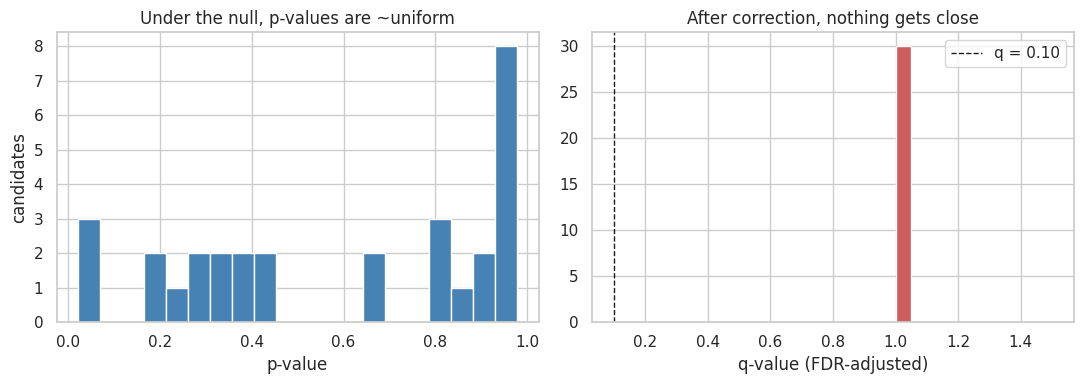

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

ax[0].hist(report.p_value, bins=20, color="steelblue", edgecolor="white")
ax[0].set_xlabel("p-value"); ax[0].set_ylabel("candidates")
ax[0].set_title("Under the null, p-values are ~uniform")

ax[1].hist(report.q_value, bins=20, color="indianred", edgecolor="white")
ax[1].axvline(0.10, ls="--", c="k", lw=1, label="q = 0.10")
ax[1].set_xlabel("q-value (FDR-adjusted)")
ax[1].set_title("After correction, nothing gets close")
ax[1].legend()

plt.tight_layout()
plt.show()


The left histogram is the tell. Under a true null, p-values are uniform on [0, 1] —
so some candidates *will* have small p-values by chance. That is not evidence. The
multiplicity correction on the right is what converts "some candidate looked good"
into "no candidate survives".


## What the alternative looks like


In [6]:
Xn_tr, Xn_te, yn_tr, yn_te = train_test_split(
    X_noise, y_noise, test_size=0.3, random_state=SEED
)

ridge = make_pipeline(StandardScaler(), RidgeCV()).fit(Xn_tr, yn_tr)
poly = make_pipeline(PolynomialFeatures(2, include_bias=False),
                     StandardScaler(), RidgeCV()).fit(Xn_tr, yn_tr)
bf = BeamFeatRegressor(max_depth=2, beam_width=30,
                       random_state=SEED).fit(Xn_tr, yn_tr)

print(f"ridge        train R2 = {ridge.score(Xn_tr, yn_tr):+.4f}   "
      f"test R2 = {ridge.score(Xn_te, yn_te):+.4f}")
print(f"poly(2)      train R2 = {poly.score(Xn_tr, yn_tr):+.4f}   "
      f"test R2 = {poly.score(Xn_te, yn_te):+.4f}")
print(f"beamfeat     train R2 = {bf.score(Xn_tr, yn_tr):+.4f}   "
      f"test R2 = {bf.score(Xn_te, yn_te):+.4f}")


ridge        train R2 = +0.0142   test R2 = -0.0769
poly(2)      train R2 = +0.2175   test R2 = -0.4893
beamfeat     train R2 = +0.0000   test R2 = -0.0415


Polynomial expansion fits the training noise and collapses on test. `beamfeat` fits
an intercept, so both numbers sit at zero — it never claimed anything to be wrong
about.


## Experiment 2: how much signal does it need?

Refusing on pure noise is easy — a tool that always refuses would pass that test.
The real question is where the threshold sits. We sweep signal strength and record
how often a genuine interaction is detected.


In [7]:
rows = []
for snr in [0.0, 0.05, 0.1, 0.2, 0.4, 0.8, 1.6]:
    detected = 0
    trials = 12
    for t in range(trials):
        r = np.random.default_rng(100 + t)
        Xp = r.normal(size=(300, 6))
        signal = Xp[:, 0] * Xp[:, 1]                 # true interaction
        yp = snr * signal / signal.std() + r.normal(size=300)

        mm = BeamFeatRegressor(max_depth=2, beam_width=30,
                               random_state=SEED).fit(Xp, yp)
        detected += int(mm.fdr_controlled_ and len(mm.formulas()) > 0)

    rows.append({"signal_to_noise": snr,
                 "detected": f"{detected}/{trials}",
                 "rate": detected / trials})

power = pd.DataFrame(rows)
power


,signal_to_noise,detected,rate
0,0.00,0/12,0.000000
1,0.05,0/12,0.000000
2,0.10,0/12,0.000000
3,0.20,1/12,0.083333
4,0.40,11/12,0.916667
5,0.80,12/12,1.000000
6,1.60,12/12,1.000000


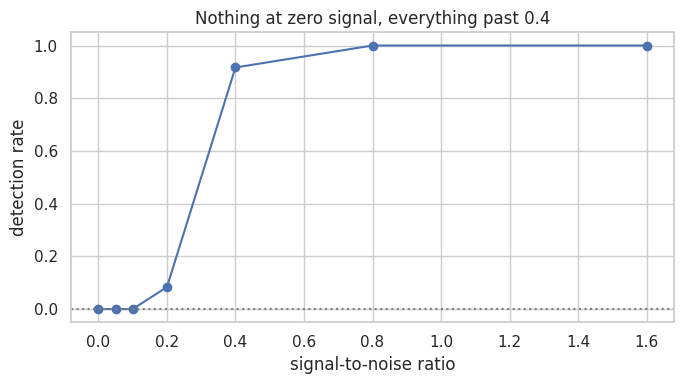

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(power.signal_to_noise, power.rate, "o-")
ax.axhline(0, ls=":", c="grey")
ax.set_xlabel("signal-to-noise ratio")
ax.set_ylabel("detection rate")
ax.set_title("Nothing at zero signal, everything past 0.4")
ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.show()


Zero detections at zero signal — no false positives across 12 runs. The transition is
sharp: still nothing at 0.1, almost everything by 0.4.

That shape is what you want. A tool that refused everywhere would be useless; a tool
that fired at 0.0 would be dishonest. Read the left end as the guarantee and the
right end as the power.


## Experiment 3: a real dataset with weak structure

The diabetes dataset has genuine but modest signal. This is the interesting middle
case — not noise, not an obvious law.


In [9]:
dia = load_diabetes()
Xd_tr, Xd_te, yd_tr, yd_te = train_test_split(
    dia.data, dia.target, test_size=0.3, random_state=SEED
)

md_ = BeamFeatRegressor(max_depth=2, beam_width=30, random_state=SEED).fit(Xd_tr, yd_tr)

ridge_d = make_pipeline(StandardScaler(), RidgeCV()).fit(Xd_tr, yd_tr)
gbm_d = HistGradientBoostingRegressor(random_state=SEED).fit(Xd_tr, yd_tr)

print(f"features kept  : {len(md_.formulas())}")
print(f"fdr_controlled_: {md_.fdr_controlled_}")
print()
print(f"ridge            R2 = {ridge_d.score(Xd_te, yd_te):.4f}")
print(f"gradient boost   R2 = {gbm_d.score(Xd_te, yd_te):.4f}")
print(f"beamfeat         R2 = {md_.score(Xd_te, yd_te):.4f}")


features kept  : 4
fdr_controlled_: True

ridge            R2 = 0.3925
gradient boost   R2 = 0.2774
beamfeat         R2 = 0.3705


`beamfeat` keeps four features, holds the guarantee, and lands at 0.371 — ahead of
gradient boosting's 0.277, just behind ridge's 0.393.

Read that as the tool working. There is no compact algebraic law hiding in the
diabetes data, so nothing should have beaten a linear model, and nothing did. What
matters is that it neither invented structure nor blew up: it stayed within a
whisker of the best baseline while continuing to report exactly what it could
certify.

Across this notebook the record is: **correct refusal on noise, correct detection
from SNR 0.4 upward, and correct restraint on weak real data.** All three are the
behaviour you want, and all three are behaviour that unguarded constructors do not
provide — `poly(2) + ridge` scored −0.49 on the same noise beamfeat declined.


## Takeaways

1. On pure noise: zero features, `fdr_controlled_ = False`, explicit warning.
2. `selection_report_` shows *why* — uniform p-values, nothing surviving correction.
3. Detection climbs from nothing at SNR 0.1 to certainty by 0.4. The refusal is not
   the tool being timid.
4. On real weak-signal data it lands at 0.371 against ridge's 0.393 and gradient
   boosting's 0.277 — no invented structure, no collapse. That is the tool working.
5. Branch on `fdr_controlled_` in code. Warnings get lost.
